In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from collections import Counter
from itertools import combinations
import os

In [2]:
# ==========================================
# PART 1: SETUP & DATA LOADING
# ==========================================

# PRE-SET PATH: Based on your request. 
# If the file name inside the 'cleans' folder is different, please edit this line.
FILENAME = '/kaggle/input/cleans/cleaned_comments.csv'

# 1. Load the data
print(f"Step 1: Loading Data from {FILENAME}...")

if not os.path.exists(FILENAME):
    # Helpful error message if the path is slightly off
    print(f"Error: File not found at {FILENAME}")
    print("Please check the file path. Common issues:")
    print("1. The dataset name in /kaggle/input/ might be slightly different.")
    print("2. The CSV file name inside the folder might not be 'cleaned_comments.csv'.")
    exit()

df = pd.read_csv(FILENAME)

# 2. Safety Check: Convert string representation of lists to actual lists
# (e.g., "['word', 'word']" -> ['word', 'word'])
if 'cleaned_tokens' in df.columns and isinstance(df['cleaned_tokens'].iloc[0], str):
    try:
        df['cleaned_tokens'] = df['cleaned_tokens'].apply(ast.literal_eval)
    except ValueError:
        print("Error: Could not convert 'cleaned_tokens' column. Ensure it follows list syntax.")

print(f"Data Loaded. Total rows: {len(df)}")

Step 1: Loading Data from /kaggle/input/cleans/cleaned_comments.csv...
Data Loaded. Total rows: 58


In [4]:
# ==========================================
# PART 2: SEGMENTATION (CHUNKING)
# ==========================================
print("\nStep 2: Splitting data into 5 chunks...")
# Use numpy to split dataframe into 5 equal parts
chunks = np.array_split(df, 5)



Step 2: Splitting data into 5 chunks...



Step 3: Mining Frequent Patterns...

--- Analyzing Chunk 1 ---
Top 5 Unigrams: [('zebra', 5), ('migration', 4), ('bbc', 3), ('earth', 3), ('way', 3)]
Top 5 Co-occurring Pairs: [(('bbc', 'earth'), 3), (('journey', 'zebra'), 3), (('always', 'way'), 2), (('always', 'zebra'), 2), (('bbc', 'beauty'), 2)]
Saved plot: chunk_1_unigrams.png


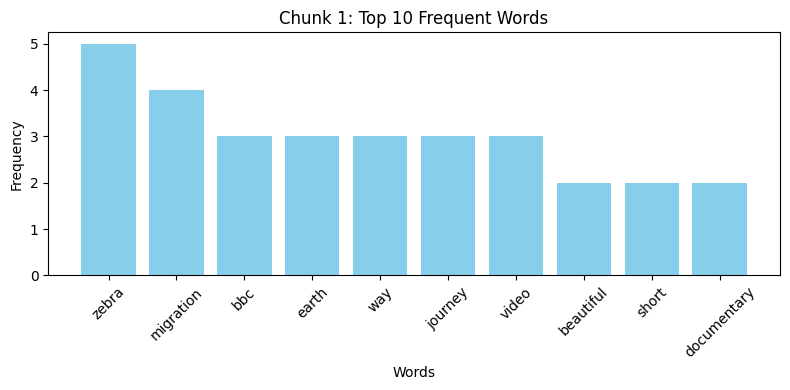


--- Analyzing Chunk 2 ---
Top 5 Unigrams: [('zebra', 4), ('either', 2), ('nature', 2), ('beautiful', 2), ('step', 2)]
Top 5 Co-occurring Pairs: [(('beautiful', 'nature'), 2), (('africana', 'belleza'), 1), (('africana', 'desafos'), 1), (('africana', 'documental'), 1), (('africana', 'impresionante'), 1)]
Saved plot: chunk_2_unigrams.png


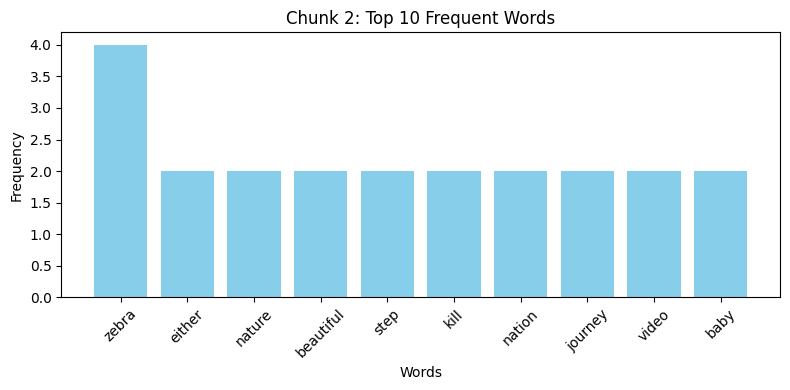


--- Analyzing Chunk 3 ---
Top 5 Unigrams: [('zebra', 4), ('life', 4), ('migration', 3), ('nature', 3), ('like', 3)]
Top 5 Co-occurring Pairs: [(('migration', 'moment'), 2), (('migration', 'nature'), 2), (('moment', 'nature'), 2), (('animal', 'zebra'), 2), (('loss', 'time'), 2)]
Saved plot: chunk_3_unigrams.png


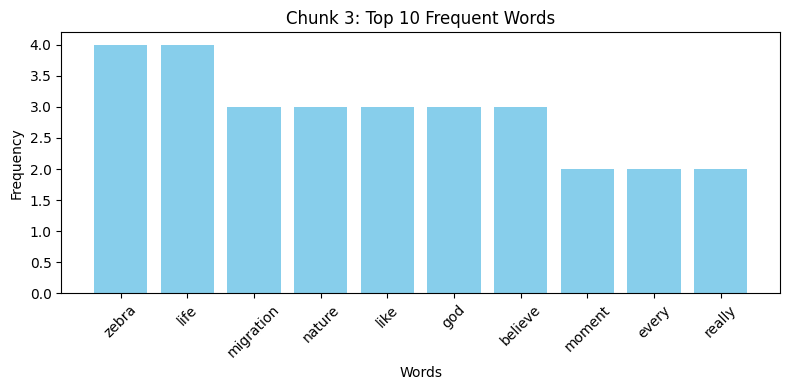


--- Analyzing Chunk 4 ---
Top 5 Unigrams: [('bbc', 2), ('another', 2), ('beautiful', 2), ('animal', 2), ('never', 2)]
Top 5 Co-occurring Pairs: [(('animal', 'never'), 2), (('bbc', 'blessing'), 1), (('bbc', 'earth'), 1), (('bbc', 'humanity'), 1), (('blessing', 'earth'), 1)]
Saved plot: chunk_4_unigrams.png


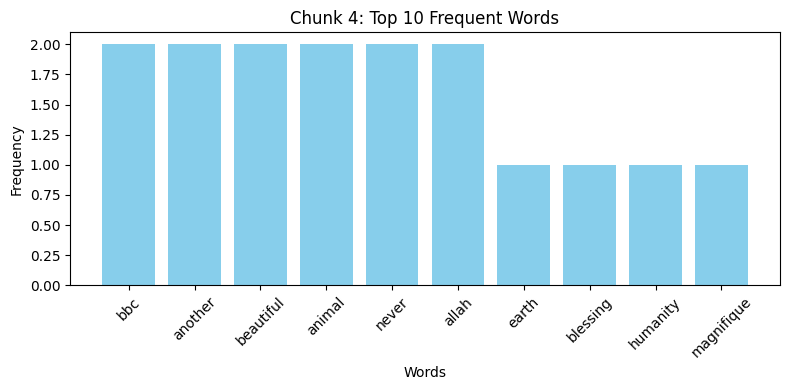


--- Analyzing Chunk 5 ---
Top 5 Unigrams: [('zebra', 3), ('please', 2), ('phylogenetically', 1), ('way', 1), ('remote', 1)]
Top 5 Co-occurring Pairs: [(('dinosaur', 'diplodocus'), 1), (('dinosaur', 'like'), 1), (('dinosaur', 'longnecked'), 1), (('dinosaur', 'movent'), 1), (('dinosaur', 'neckhead'), 1)]
Saved plot: chunk_5_unigrams.png


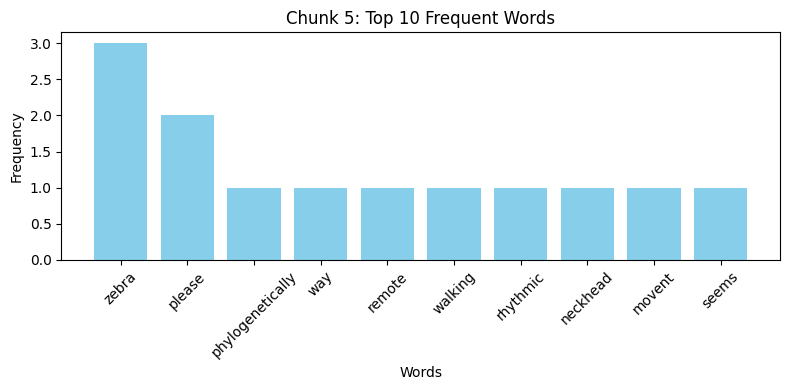

In [6]:
# ==========================================
# PART 3: MINING PATTERNS PER CHUNK
# ==========================================
print("\nStep 3: Mining Frequent Patterns...")

# We will store the full frequency counts of every word found to use in Step 4
# Dictionary structure: { 'word': [count_chunk1, count_chunk2, ...], ... }
tracker_data = {} 
all_unique_words = set()

for i, chunk in enumerate(chunks):
    chunk_id = i + 1
    print(f"\n--- Analyzing Chunk {chunk_id} ---")
    
    # Extract all transactions (lists of tokens)
    # Ensure we handle potential NaN values by treating them as empty lists
    transactions = chunk['cleaned_tokens'].dropna().tolist()
    
    # A. Flatten to find Top Unigrams (Individual words)
    all_tokens = [token for row in transactions for token in row]
    unigram_counts = Counter(all_tokens)
    top_unigrams = unigram_counts.most_common(10)
    
    print(f"Top 5 Unigrams: {top_unigrams[:5]}")

    # Update global tracker for correlation later
    # 1. Add new words to set
    current_chunk_words = set(unigram_counts.keys())
    all_unique_words.update(current_chunk_words)
    
    # B. Find Top Co-occurring Pairs (Itemsets)
    bigram_counts = Counter()
    for row in transactions:
        # sorted(set(row)) ensures we don't count ('a','b') and ('b','a') separately
        # and ignore duplicates within the same comment
        unique_row_tokens = sorted(list(set(row)))
        bigram_counts.update(combinations(unique_row_tokens, 2))
    
    top_bigrams = bigram_counts.most_common(10)
    print(f"Top 5 Co-occurring Pairs: {top_bigrams[:5]}")

    # C. Visualization for this Chunk
    # We plot the Top 10 Unigrams for this specific chunk
    if top_unigrams:
        words, counts = zip(*top_unigrams)
        plt.figure(figsize=(8, 4))
        plt.bar(words, counts, color='skyblue')
        plt.title(f'Chunk {chunk_id}: Top 10 Frequent Words')
        plt.xlabel('Words')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45)
        plt.tight_layout()
        
        # Save the plot
        plot_filename = f'chunk_{chunk_id}_unigrams.png'
        plt.savefig(plot_filename)
        print(f"Saved plot: {plot_filename}")
        
        plt.show() # Display chart (close window to continue loop)


In [7]:
# ==========================================
# PART 4 & 5: TRACKING & FREQUENCY SERIES
# ==========================================
print("\nStep 4 & 5: Building Frequency Series for Correlation...")

# 1. Construct the full history dataframe
# We need to go back and count specific words in every chunk to ensure 0s are recorded
# Logic: We pick specific interesting patterns. 
# For this lab, we will auto-select the Top 5 most frequent words from the *entire* dataset
# to ensure we have interesting data to plot. 

# Combine all chunks to find global top words
global_tokens = [t for row in df['cleaned_tokens'].dropna() for t in row]
global_top_5 = [word for word, count in Counter(global_tokens).most_common(5)]

print(f"Selected patterns for correlation analysis: {global_top_5}")
print("(Note: You can manually change the 'patterns_to_track' list in the code to specific words like 'exam', 'video', etc.)")

# You can manually overwrite this list if you want to look for specific things:
patterns_to_track = global_top_5 
# patterns_to_track = ['exam', 'video', 'stress', 'like'] # Example manual override

# Initialize data structure
freq_data = {pattern: [] for pattern in patterns_to_track}

# Populate counts
for chunk in chunks:
    tokens_in_chunk = [t for row in chunk['cleaned_tokens'].dropna() for t in row]
    chunk_counter = Counter(tokens_in_chunk)
    
    for pattern in patterns_to_track:
        freq_data[pattern].append(chunk_counter[pattern])

# Create DataFrame
freq_df = pd.DataFrame(freq_data, index=[f'Chunk {i+1}' for i in range(5)])

print("\nFrequency Data Table:")
print(freq_df)

# Save the frequency dataframe to CSV
freq_df.to_csv('pattern_frequencies.csv')
print("Saved file: pattern_frequencies.csv")


Step 4 & 5: Building Frequency Series for Correlation...
Selected patterns for correlation analysis: ['zebra', 'beautiful', 'nature', 'migration', 'journey']
(Note: You can manually change the 'patterns_to_track' list in the code to specific words like 'exam', 'video', etc.)

Frequency Data Table:
         zebra  beautiful  nature  migration  journey
Chunk 1      5          2       2          4        3
Chunk 2      4          2       2          1        2
Chunk 3      4          2       3          3        1
Chunk 4      1          2       1          0        0
Chunk 5      3          1       1          0        1
Saved file: pattern_frequencies.csv



Step 6: Calculating Correlation...

Correlation Matrix:
              zebra  beautiful    nature  migration   journey
zebra      1.000000   0.147442  0.669894   0.798549  0.896388
beautiful  0.147442   1.000000  0.534522   0.492366  0.196116
nature     0.669894   0.534522  1.000000   0.756644  0.366900
migration  0.798549   0.492366  0.756644   1.000000  0.700067
journey    0.896388   0.196116  0.366900   0.700067  1.000000
Saved file: correlation_matrix.csv
Saved plot: trend_analysis.png


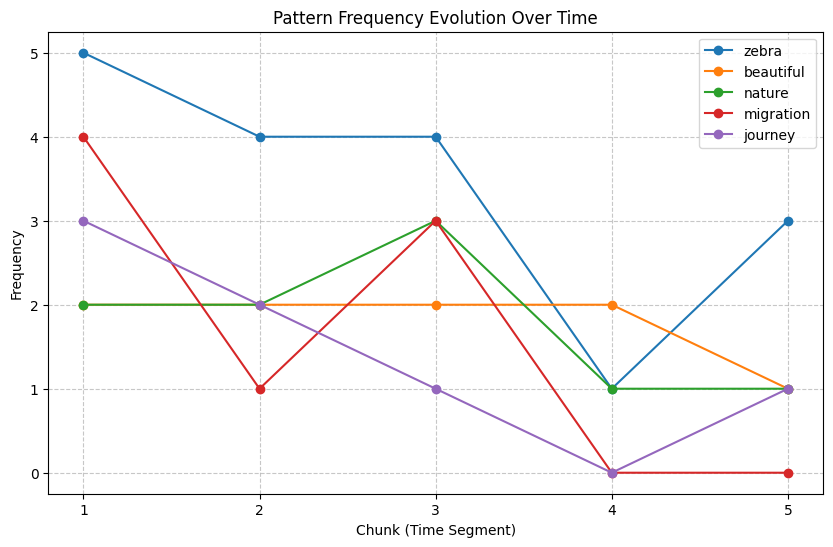


Analysis Complete.


In [9]:
# ==========================================
# PART 6: CORRELATION ANALYSIS
# ==========================================
print("\nStep 6: Calculating Correlation...")

# Compute Correlation Matrix
corr_matrix = freq_df.corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Save the correlation matrix to CSV
corr_matrix.to_csv('correlation_matrix.csv')
print("Saved file: correlation_matrix.csv")

# Visualization: Trend Lines
plt.figure(figsize=(10, 6))
for column in freq_df.columns:
    plt.plot(range(1, 6), freq_df[column], marker='o', label=column)

plt.xlabel('Chunk (Time Segment)')
plt.ylabel('Frequency')
plt.title('Pattern Frequency Evolution Over Time')
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Save the trend plot
plt.savefig('trend_analysis.png')
print("Saved plot: trend_analysis.png")

plt.show()

print("\nAnalysis Complete.")
